In [8]:
from datetime import time
from os import times
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.patches as patches
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import math
from cartopy.mpl.ticker import LongitudeFormatter,LatitudeFormatter

#math的相关函数，import后可以直接使用
from math import radians
from math import sin
from math import cos
from math import asin
from math import sqrt

# np.set_printoptions(threshold=np.inf)#显示所有的数组
from geopy.distance import great_circle
from geopy.distance import geodesic
import matplotlib
# matplotlib.rcParams['font.family'] = 'Times New Roman'
import seaborn as sns
from scipy import stats

# from jupyterthemes import jtplot
# jtplot.style()


In [9]:
# 计算弯曲度的函数
def calculate_sinuosity(latitudes, longitudes):
    # 计算路径的实际长度
    path_length = 0
    for i in range(1, len(latitudes)):
        point1 = (latitudes[i-1], longitudes[i-1])
        point2 = (latitudes[i], longitudes[i])
        path_length += geodesic(point1, point2).km
    
    # 计算起点和终点的直线距离
    start_point = (latitudes[0], longitudes[0])
    end_point = (latitudes[-1], longitudes[-1])
    straight_line_distance = geodesic(start_point, end_point).km
    
    # 计算弯曲度
    sinuosity = path_length / straight_line_distance
    return sinuosity

In [10]:
ds = xr.open_dataset('D:/data/GFDL/ECMWF/TC-NH_TRACK_ECMWF-IFS-HR_highresSST-present_r1i1p1f1_gr_19500101-20141231.nc')

In [11]:
min_lon = 100
max_lon = 180
min_lat = 0
max_lat = 30

In [12]:
import pandas as pd
import numpy as np
import cftime

res_sinuosity = []
res_frequency = []

for yearlis in range(1982, 2015):

    tracks_year = []

    # 遍历所有台风
    for i in range(ds.sizes['tracks']):
        start_index = ds['FIRST_PT'].isel(tracks=i).item()
        num_pts = ds['NUM_PTS'].isel(tracks=i).item()
        
        latitudes = ds['lat'].isel(record=slice(start_index, start_index + num_pts)).values
        longitudes = ds['lon'].isel(record=slice(start_index, start_index + num_pts)).values
        times = ds['time'].isel(record=slice(start_index, start_index + num_pts)).values

        # ✅ 修复：转换时间类型
        if isinstance(times[0], cftime.DatetimeNoLeap):
            times = [pd.Timestamp(t.strftime("%Y-%m-%d %H:%M:%S")) for t in times]
        else:
            times = pd.to_datetime(times)

        # 检查是否经过西北太平洋
        is_nw_pacific = any(
            (min_lon <= lon <= max_lon) and (min_lat <= lat <= max_lat)
            for lat, lon in zip(latitudes, longitudes)
        )

        if is_nw_pacific:
            first_time_dt = times[0]
            last_time_dt = times[-1]

            # 计算持续时间（小时）
            duration = (last_time_dt - first_time_dt).total_seconds() / 3600

            # 获取风速并计算最大风速（节）
            wind_speeds = ds['sfcWind'].isel(record=slice(start_index, start_index + num_pts)).values
            max_wind_speed = np.max(wind_speeds) * 1.9438

            # 筛选条件
            if first_time_dt.year == yearlis and 7 <= first_time_dt.month <= 10 and duration > 48 and max_wind_speed > 17.2:
                track_id = ds['TRACK_ID'].isel(tracks=i).item()
                track_data = ds.isel(record=slice(start_index, start_index + num_pts))

                tracks_year.append({
                    'track_id': track_id,
                    'start_time': first_time_dt,
                    'duration': duration,
                    'max_wind_speed': max_wind_speed,
                    'start_lat': latitudes[0],
                    'start_lon': longitudes[0],
                    'data': track_data
                })

    # 保存频数
    res_frequency.append(len(tracks_year))

    # 计算弯曲度
    sinuosity_values = []
    for track in tracks_year:
        latitudes = track['data']['lat'].values
        longitudes = track['data']['lon'].values

        sinuosity = calculate_sinuosity(latitudes, longitudes)

        if sinuosity < 5:
            sinuosity_values.append(sinuosity)

    average_sinuosity = np.mean(sinuosity_values) if sinuosity_values else 0
    res_sinuosity.append(average_sinuosity)

# 输出结果
for y, freq, sinu in zip(range(2015, 2050), res_frequency, res_sinuosity):
    print(f"{y}年7-10月：符合条件的台风数={freq}，平均弯曲度={sinu:.3f}")


2015年7-10月：符合条件的台风数=20，平均弯曲度=1.857
2016年7-10月：符合条件的台风数=16，平均弯曲度=1.815
2017年7-10月：符合条件的台风数=23，平均弯曲度=1.626
2018年7-10月：符合条件的台风数=22，平均弯曲度=1.875
2019年7-10月：符合条件的台风数=23，平均弯曲度=1.635
2020年7-10月：符合条件的台风数=24，平均弯曲度=1.731
2021年7-10月：符合条件的台风数=23，平均弯曲度=1.955
2022年7-10月：符合条件的台风数=17，平均弯曲度=1.890
2023年7-10月：符合条件的台风数=16，平均弯曲度=1.782
2024年7-10月：符合条件的台风数=18，平均弯曲度=1.676
2025年7-10月：符合条件的台风数=25，平均弯曲度=1.737
2026年7-10月：符合条件的台风数=20，平均弯曲度=1.821
2027年7-10月：符合条件的台风数=27，平均弯曲度=1.878
2028年7-10月：符合条件的台风数=19，平均弯曲度=1.414
2029年7-10月：符合条件的台风数=29，平均弯曲度=1.898
2030年7-10月：符合条件的台风数=14，平均弯曲度=2.063
2031年7-10月：符合条件的台风数=11，平均弯曲度=1.665
2032年7-10月：符合条件的台风数=16，平均弯曲度=1.883
2033年7-10月：符合条件的台风数=19，平均弯曲度=1.814
2034年7-10月：符合条件的台风数=25，平均弯曲度=2.078
2035年7-10月：符合条件的台风数=15，平均弯曲度=1.953
2036年7-10月：符合条件的台风数=21，平均弯曲度=1.980
2037年7-10月：符合条件的台风数=27，平均弯曲度=1.662
2038年7-10月：符合条件的台风数=13，平均弯曲度=1.804
2039年7-10月：符合条件的台风数=21，平均弯曲度=2.045
2040年7-10月：符合条件的台风数=15，平均弯曲度=1.639
2041年7-10月：符合条件的台风数=18，平均弯曲度=1.838
2042年7-10月：符合条件的台风数=21，平均弯曲度=1.760
2043年7-10月：符合条件的台风数=

In [13]:
res_sinuosity

[np.float64(1.8568662141075685),
 np.float64(1.8146048810909463),
 np.float64(1.6263062214279635),
 np.float64(1.8753829448046972),
 np.float64(1.6351552073640014),
 np.float64(1.7311001419723329),
 np.float64(1.9549379148863681),
 np.float64(1.8901099463142848),
 np.float64(1.7818490576438863),
 np.float64(1.67630295385487),
 np.float64(1.7374854247146814),
 np.float64(1.8205540513680993),
 np.float64(1.8781061333419204),
 np.float64(1.413587221263257),
 np.float64(1.8981188431884042),
 np.float64(2.0632935734794176),
 np.float64(1.6645196376544042),
 np.float64(1.8826006451343922),
 np.float64(1.814185848051458),
 np.float64(2.0775920726281494),
 np.float64(1.9526393545111984),
 np.float64(1.9803795267987334),
 np.float64(1.6621357938956598),
 np.float64(1.8044262685476762),
 np.float64(2.0448672368546337),
 np.float64(1.6388354236341398),
 np.float64(1.837659562052134),
 np.float64(1.7602528019163346),
 np.float64(1.6650334785872543),
 np.float64(1.685066597974704),
 np.float64(1.63

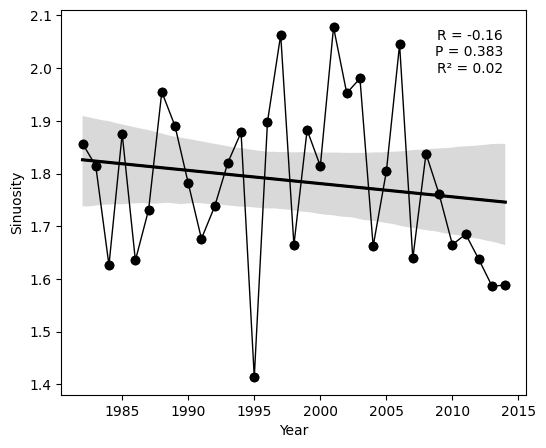

R: -0.1568635978411752
P: 0.3833271807336758
R2: 0.02460618832767795


In [14]:
years = np.arange(1982, 2015)
x=years
y=res_sinuosity
#........................................................................................................   
fig, ax = plt.subplots(figsize=(6, 5))
# 计算线性回归
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
# 计算 R 方
r_squared = r_value ** 2
ax = sns.regplot(x=x, y=y, ci=95,color='black')
# 绘制散点图和回归线
plt.plot(x,y,'k-o', alpha=1, linewidth=1)
plt.plot(x, intercept + slope * np.array(x), 'black')
textstr = f"R = {r_value:.2f}\nP = {p_value:.3f}\nR² = {r_squared:.2f}"
ax.text(0.95, 0.95, textstr, transform=ax.transAxes,
        fontsize=10, va='top', ha='right')
plt.xlabel('Year')
plt.ylabel('Sinuosity')
plt.show()
print('R:',r_value)
print('P:', p_value)
print('R2:', r_squared)